# Clinical Question Set Design
## Protocol-Grounded Evaluation Questions for AI Chatbot Assessment

**Purpose:** Build and validate the 15 clinical questions used in Phase II
chatbot evaluation. Questions are derived through stratified purposive sampling
across 5 clinical domains identified from KMeans clustering (Chapter 3.5).

**Pipeline:**
1. Define 15 questions across 5 strata, anchored to real protocol filenames
2. Load EN corpus sections and embed with multilingual MPNet
3. Coverage validation — every question must reach cosine ≥ 0.50 to its target protocol
4. NER entity validation — confirm expected entities exist in each target protocol
5. Visualise domain distribution and coverage scores
6. Export `final_questions.json` for Phase II evaluation pipeline

**Thesis reference:** Chapter 3, Section 3.6 — Question Set Construction

## 1. Install & Imports

In [ ]:
# Step 1 — install, then restart runtime
!pip install -q sentence-transformers scikit-learn matplotlib seaborn pandas numpy tqdm
print("Install done — restart runtime before continuing.")

Install done — restart runtime before continuing.


> ⚠️ **Restart runtime after the cell above**, then continue from here.

In [ ]:
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import torch

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
print("All imports OK")

All imports OK


## 2. Drive & Config

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# ── Paths ────────────────────────────────────────────────────────────────────
EN_DIR       = Path("/content/drive/MyDrive/medical_protocols/en_aux_v1_fixed")
NER_DIR      = Path("/content/drive/MyDrive/medical_protocols/ner/en_biobert_v1")
TOP2VEC_CSV  = Path("/content/drive/MyDrive/medical_protocols/top2vec/top2vec_topics_EN.csv")
OUT_DIR      = Path("/content/drive/MyDrive/medical_protocols/question_design_v1")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────────
MIN_CHARS          = 200
COVERAGE_THRESHOLD = 0.50
MODEL_NAME         = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

print(f"EN_DIR  : {EN_DIR}")
print(f"NER_DIR : {NER_DIR}")
print(f"OUT_DIR : {OUT_DIR}")
print(f"Coverage threshold : {COVERAGE_THRESHOLD}")

EN_DIR  : /content/drive/MyDrive/medical_protocols/en_aux_v1_fixed
NER_DIR : /content/drive/MyDrive/medical_protocols/ner/en_biobert_v1
OUT_DIR : /content/drive/MyDrive/medical_protocols/question_design_v1
Coverage threshold : 0.5


## 3. Question Set Definition

Questions derived through stratified purposive sampling across 5 clinical domains.
Each question is anchored to a specific protocol filename and includes expected
NER entities for entity-level evaluation in Phase II.

In [ ]:

CANDIDATE_QUESTIONS = [

    # ── Stratum A: Diagnosis & Criteria (Clusters 0 + 4) ─────────────────────
    {
        "id": "A1",
        "stratum": "Diagnosis & Criteria",
        "question_en": "What are the diagnostic criteria for severe preeclampsia, and what blood pressure thresholds are used for classification?",
        "question_ru": "Каковы диагностические критерии тяжёлой преэклампсии и какие пороговые значения артериального давления используются для классификации?",
        "target_protocol": "en_Гипертензивные_состояния_при_беременности.md",
        "expected_entities": ["magnesium sulfate"],  # only entity reliably extracted by BioBERT; antihypertensives listed as thesis limitation
        "clinical_rationale": "Tests knowledge of KZ-specific BP thresholds and diagnostic criteria for preeclampsia severity classification",
    },
    {
        "id": "A2",
        "stratum": "Diagnosis & Criteria",
        "question_en": "What fasting glucose and oral glucose tolerance test thresholds are used to diagnose gestational diabetes mellitus?",
        "question_ru": "Какие пороговые значения глюкозы натощак и перорального глюкозотолерантного теста используются для диагностики гестационного сахарного диабета?",
        "target_protocol": "en_Сахарный_диабет_при_беременности,_в_родах_и_послеродовом_периоде.md",
        "expected_entities": ["insulin", "metformin", "glucose"],
        "clinical_rationale": "Tests protocol-specific diagnostic thresholds which differ from WHO and ADA general guidelines",
    },
    {
        "id": "A3",
        "stratum": "Diagnosis & Criteria",
        "question_en": "What clinical and laboratory criteria define septic shock in obstetric patients, and what scoring systems are recommended?",
        "question_ru": "Какие клинические и лабораторные критерии определяют септический шок у акушерских пациенток и какие шкалы оценки рекомендованы?",
        "target_protocol": "en_Акушерский_сепсис.md",
        "expected_entities": ["norepinephrine", "dopamine", "hydrocortisone"],
        "clinical_rationale": "Tests knowledge of SOFA/qSOFA criteria application in obstetric sepsis context",
    },

    # ── Stratum B: Pharmacotherapy (Cluster 1) ────────────────────────────────
    {
        "id": "B1",
        "stratum": "Pharmacotherapy",
        "question_en": "What is the recommended first-line antihypertensive therapy for severe preeclampsia, and what are the specific dosages?",
        "question_ru": "Какова рекомендуемая антигипертензивная терапия первой линии при тяжёлой преэклампсии и каковы конкретные дозировки?",
        "target_protocol": "en_Гипертензивные_состояния_при_беременности.md",
        "expected_entities": ["magnesium sulfate"],  # BioBERT recall low for antihypertensives in this protocol
        "clinical_rationale": "Tests drug selection and dosing — high entity density makes it ideal for entity-level recall metric",
    },
    {
        "id": "B2",
        "stratum": "Pharmacotherapy",
        "question_en": "What empirical antibiotic regimen is recommended for obstetric sepsis, and within what timeframe should it be initiated?",
        "question_ru": "Какая эмпирическая антибиотикотерапия рекомендована при акушерском сепсисе и в какие сроки она должна быть начата?",
        "target_protocol": "en_Акушерский_сепсис.md",
        "expected_entities": ["ceftriaxone", "metronidazole", "amikacin"],
        "clinical_rationale": "Strongest entity-level test — 5 expected drugs, protocol-specific timeframe (1 hour) not in general knowledge",
    },
    {
        "id": "B3",
        "stratum": "Pharmacotherapy",
        "question_en": "What tocolytic agents are recommended for preterm labour, and what are the contraindications to their use?",
        "question_ru": "Какие токолитические препараты рекомендованы при угрозе преждевременных родов и каковы противопоказания к их применению?",
        "target_protocol": "en_Преждевременные_роды.md",
        "expected_entities": ["atosiban", "dexamethasone"],
        "clinical_rationale": "Tests tocolytic selection and corticosteroid lung maturation — both protocol-specific",
    },

    # ── Stratum C: Surgical & Emergency (Clusters 2 + 11) ────────────────────
    {
        "id": "C1",
        "stratum": "Surgical & Emergency",
        "question_en": "What are the stepwise surgical interventions recommended for postpartum haemorrhage that does not respond to uterotonic therapy?",
        "question_ru": "Каковы поэтапные хирургические вмешательства, рекомендованные при послеродовом кровотечении, не отвечающем на утеротоническую терапию?",
        "target_protocol": "en_Послеродовое_кровотечение.md",
        "expected_entities": ["oxytocin", "tranexamic acid"],
        "clinical_rationale": "Tests step-by-step escalation logic — B-Lynch suture, uterine artery ligation, hysterectomy sequence",
    },
    {
        "id": "C2",
        "stratum": "Surgical & Emergency",
        "question_en": "What are the indications for emergency hysterectomy in obstetric patients according to clinical guidelines?",
        "question_ru": "Каковы показания к экстренной гистерэктомии у акушерских пациенток согласно клиническим протоколам?",
        "target_protocol": "en_Послеродовое_кровотечение.md",
        "expected_entities": ["oxytocin", "tranexamic acid"],
        "clinical_rationale": "Tests escalation endpoint — chatbot must know hysterectomy is last resort after specific failed steps",
    },
    {
        "id": "C3",
        "stratum": "Surgical & Emergency",
        "question_en": "What are the clinical signs and immediate management steps for suspected uterine rupture during labour?",
        "question_ru": "Каковы клинические признаки и неотложные меры при подозрении на разрыв матки в процессе родов?",
        "target_protocol": "en_Аномалии_родовой_деятельности.md",
        "expected_entities": [],  # uterine rupture management is surgical; no medication entities expected
        "clinical_rationale": "Tests emergency recognition and escalation — requires protocol-specific surgical decision pathway",
    },

    # ── Stratum D: Monitoring & Screening (Clusters 3 + 10) ──────────────────
    {
        "id": "D1",
        "stratum": "Monitoring & Screening",
        "question_en": "What antenatal screening tests are recommended during the first trimester, and at what gestational weeks should they be performed?",
        "question_ru": "Какие скрининговые исследования рекомендованы в первом триместре беременности и на каких неделях гестации они должны проводиться?",
        "target_protocol": "en_Антенатальный_уход.md",
        "expected_entities": [],
        "clinical_rationale": "Tests protocol-specific screening schedule (weeks 10-14 combined screening) vs generic advice",
    },
    {
        "id": "D2",
        "stratum": "Monitoring & Screening",
        "question_en": "What glucose monitoring targets are recommended for patients with gestational diabetes mellitus during pregnancy?",
        "question_ru": "Какие целевые показатели гликемии рекомендованы для пациенток с гестационным сахарным диабетом во время беременности?",
        "target_protocol": "en_Сахарный_диабет_при_беременности,_в_родах_и_послеродовом_периоде.md",
        "expected_entities": ["insulin", "metformin"],
        "clinical_rationale": "Tests specific numeric glucose targets — these are protocol-defined and differ from general diabetes guidelines",
    },
    {
        "id": "D3",
        "stratum": "Monitoring & Screening",
        "question_en": "What risk factors identify pregnant women who should receive progesterone prophylaxis for preterm birth prevention?",
        "question_ru": "Какие факторы риска позволяют выявить беременных женщин, которым показана профилактика прогестероном для предотвращения преждевременных родов?",
        "target_protocol": "en_Преждевременные_роды.md",
        "expected_entities": ["progesterone"],
        "clinical_rationale": "Tests prevention logic — cervical length threshold and prior preterm birth criteria are protocol-specific",
    },

    # ── Stratum E: Infection & Sepsis (Cluster 8) ─────────────────────────────
    {
        "id": "E1",
        "stratum": "Infection & Sepsis",
        "question_en": "What are the diagnostic criteria for chorioamnionitis and what is the recommended antibiotic protocol?",
        "question_ru": "Каковы диагностические критерии хориоамнионита и какова рекомендуемая схема антибиотикотерапии?",
        "target_protocol": "en_Хориоамнионит.md",
        "expected_entities": ["ampicillin", "gentamicin", "clindamycin"],
        "clinical_rationale": "Tests infection diagnosis + antibiotic protocol — both require protocol-specific knowledge",
    },
    {
        "id": "E2",
        "stratum": "Infection & Sepsis",
        "question_en": "What monitoring parameters should be assessed hourly in a patient with obstetric sepsis managed in the ICU?",
        "question_ru": "Какие параметры мониторинга необходимо оценивать каждый час у пациентки с акушерским сепсисом, находящейся в ОРИТ?",
        "target_protocol": "en_Акушерский_сепсис.md",
        "expected_entities": ["norepinephrine", "dopamine"],
        "clinical_rationale": "Tests ICU monitoring protocol — diuresis, lactate, MAP targets are guideline-specific",
    },
    {
        "id": "E3",
        "stratum": "Infection & Sepsis",
        "question_en": "What are the criteria for diagnosing postpartum endometritis and what is the first-line treatment regimen?",
        "question_ru": "Каковы критерии диагностики послеродового эндометрита и какова схема лечения первой линии?",
        "target_protocol": "en_Послеродовый_эндометрит.md",
        "expected_entities": ["clindamycin", "ampicillin", "metronidazole"],
        "clinical_rationale": "Tests postpartum infection diagnosis and treatment — antibiotic choice differs from general pelvic infection guidelines",
    },
]

df_q = pd.DataFrame(CANDIDATE_QUESTIONS)
print(f"Questions defined: {len(df_q)}")
print(f"Strata covered  : {df_q['stratum'].nunique()}")
display(df_q[["id", "stratum", "target_protocol", "question_en"]])

Questions defined: 15
Strata covered  : 5


,id,stratum,target_protocol,question_en
0,A1,Diagnosis & Criteria,en_Гипертензивные_состояния_при_беременности.md,What are the diagnostic criteria for severe pr...
1,A2,Diagnosis & Criteria,"en_Сахарный_диабет_при_беременности,_в_родах_и...",What fasting glucose and oral glucose toleranc...
2,A3,Diagnosis & Criteria,en_Акушерский_сепсис.md,What clinical and laboratory criteria define s...
3,B1,Pharmacotherapy,en_Гипертензивные_состояния_при_беременности.md,What is the recommended first-line antihyperte...
4,B2,Pharmacotherapy,en_Акушерский_сепсис.md,What empirical antibiotic regimen is recommend...
5,B3,Pharmacotherapy,en_Преждевременные_роды.md,What tocolytic agents are recommended for pret...
6,C1,Surgical & Emergency,en_Послеродовое_кровотечение.md,What are the stepwise surgical interventions r...
7,C2,Surgical & Emergency,en_Послеродовое_кровотечение.md,What are the indications for emergency hystere...
8,C3,Surgical & Emergency,en_Аномалии_родовой_деятельности.md,What are the clinical signs and immediate mana...
9,D1,Monitoring & Screening,en_Антенатальный_уход.md,What antenatal screening tests are recommended...


## 4. Corpus File Verification

Confirm every target protocol exists in `en_aux_v1_fixed/` before running validation.

In [ ]:
import unicodedata
def nfc(s): return unicodedata.normalize("NFC", str(s))

print("Verifying target protocol files...\n")
targets = df_q["target_protocol"].unique()
all_ok = True
for fname in sorted(targets):
    fname_nfc = nfc(fname)
    path = EN_DIR / fname_nfc
    if path.exists():
        chars = len(path.read_text(encoding="utf-8", errors="ignore"))
        print(f"  {fname} ({chars:,} chars)")
    else:
        print(f"  MISSING: {fname}")
        all_ok = False

print()
if all_ok:
    print("All target protocols confirmed in corpus.")
else:
    print("Fix missing filenames before continuing.")

Verifying target protocol files...

  ✅ en_Акушерский_сепсис.md (71,462 chars)
  ✅ en_Аномалии_родовой_деятельности.md (37,722 chars)
  ✅ en_Антенатальный_уход.md (99,263 chars)
  ✅ en_Гипертензивные_состояния_при_беременности.md (61,206 chars)
  ✅ en_Послеродовое_кровотечение.md (61,338 chars)
  ✅ en_Послеродовый_эндометрит.md (30,252 chars)
  ✅ en_Преждевременные_роды.md (36,768 chars)
  ✅ en_Сахарный_диабет_при_беременности,_в_родах_и_послеродовом_периоде.md (51,337 chars)
  ✅ en_Хориоамнионит.md (18,352 chars)

All target protocols confirmed in corpus.


## 5. NER Entity Validation

For each question, check whether the `expected_entities` were actually extracted
by BioBERT from the target protocol (score ≥ 0.70). Low recall here means the
entity may not appear in NER output — update `expected_entities` accordingly.

In [ ]:
import unicodedata
def nfc(s): return unicodedata.normalize("NFC", str(s))

SCORE_THRESH  = 0.70
ALLOWED_TYPES = {"Medication", "Disease_disorder",
                 "Diagnostic_procedure", "Therapeutic_procedure"}

def normalize_word(w):
    import re
    return re.sub(r"[^\w\s\-]", "", w.lower().strip())

def get_ner_entities(protocol_filename: str) -> set:
    """Load NER entities for a protocol file, return normalized set."""
    stem = nfc(Path(protocol_filename).stem)          # en_Акушерский_сепсис
    ner_name = stem.replace("en_", "ner_") + ".json"
    ner_path = NER_DIR / ner_name
    if not ner_path.exists():
        return set()
    data = json.loads(ner_path.read_text(encoding="utf-8"))
    entities = set()
    for e in data.get("entities", []):
        if float(e.get("score", 0)) >= SCORE_THRESH:
            if e.get("entity_group", "") in ALLOWED_TYPES:
                entities.add(normalize_word(e.get("word", "")))
    return entities

ner_rows = []
for _, row in df_q.iterrows():
    ner_ents = get_ner_entities(row["target_protocol"])
    expected = [normalize_word(e) for e in row["expected_entities"]]
    found    = [e for e in expected if e in ner_ents]
    missing  = [e for e in expected if e not in ner_ents]
    recall   = len(found) / len(expected) if expected else None
    ner_rows.append({
        "id":             row["id"],
        "stratum":        row["stratum"],
        "n_expected":     len(expected),
        "n_found":        len(found),
        "recall":         round(recall, 2) if recall is not None else "N/A",
        "found":          found,
        "missing":        missing,
        "ner_total_ents": len(ner_ents),
    })

df_ner = pd.DataFrame(ner_rows)
print("NER entity validation per question:")
display(df_ner[["id", "stratum", "n_expected", "n_found", "recall", "missing"]])

# Warn on low recall
low = df_ner[df_ner["n_expected"] > 0]
low = low[low["recall"].apply(lambda x: isinstance(x, float) and x < 0.50)]
if len(low):
    print(f"\n {len(low)} question(s) have NER recall < 0.50 — consider revising expected_entities")
    display(low[["id", "recall", "missing"]])

NER entity validation per question:


,id,stratum,n_expected,n_found,recall,missing
0,A1,Diagnosis & Criteria,1,1,1.0,[]
1,A2,Diagnosis & Criteria,3,3,1.0,[]
2,A3,Diagnosis & Criteria,3,3,1.0,[]
3,B1,Pharmacotherapy,1,1,1.0,[]
4,B2,Pharmacotherapy,3,3,1.0,[]
5,B3,Pharmacotherapy,2,2,1.0,[]
6,C1,Surgical & Emergency,2,2,1.0,[]
7,C2,Surgical & Emergency,2,2,1.0,[]
8,C3,Surgical & Emergency,0,0,N/A,[]
9,D1,Monitoring & Screening,0,0,N/A,[]


## 6. Load & Embed Corpus Sections

In [ ]:
import unicodedata
def nfc(s): return unicodedata.normalize("NFC", str(s))

def split_markdown_sections(md_text: str, min_chars: int = 200):
    md_text = md_text.replace("\r\n", "\n").strip()
    parts = re.split(r"(?=^##\s+)", md_text, flags=re.M)
    out = []
    for part in parts:
        part = part.strip()
        if not part: continue
        lines = part.splitlines()
        if lines and lines[0].startswith("##"):
            title = lines[0].lstrip("#").strip()
            body  = "\n".join(lines[1:]).strip()
        else:
            title = "NO_HEADER"
            body  = part
        if len(body) >= min_chars:
            out.append((title, body))
    return out

rows = []
for fp in tqdm(sorted(EN_DIR.glob("en_*.md")), desc="Loading sections"):
    text = fp.read_text(encoding="utf-8", errors="ignore")
    for i, (title, body) in enumerate(split_markdown_sections(text, MIN_CHARS)):
        rows.append({"file": nfc(fp.name), "section_id": i,
                     "title": title, "text": body})

df_sec = pd.DataFrame(rows)
print(f"EN protocols : {df_sec['file'].nunique()}")
print(f"EN sections  : {len(df_sec)}")

Loading sections: 100%|██████████| 84/84 [00:24<00:00,  3.37it/s]

EN protocols : 84
EN sections  : 2029


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model  = SentenceTransformer(MODEL_NAME, device=device)
print(f"Model loaded on {device}")

print(f"Embedding {len(df_sec)} sections...")
sec_vecs = model.encode(
    df_sec["text"].tolist(), batch_size=64,
    show_progress_bar=True, convert_to_numpy=True
)

print("Embedding questions...")
q_vecs = model.encode(
    df_q["question_en"].tolist(), convert_to_numpy=True
)
print("Done.")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded on cuda
Embedding 2029 sections...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Embedding questions...
Done.


## 7. Coverage Validation

Every question must achieve cosine similarity ≥ 0.50 to at least one section
of its designated target protocol. Questions below threshold need rephrasing.

In [ ]:

sim_matrix = cosine_similarity(q_vecs, sec_vecs)  # (n_q, n_sections)

cov_rows = []
for qi, row in df_q.iterrows():
    sims = sim_matrix[qi]

    best_global_idx  = int(np.argmax(sims))
    best_global_sim  = float(sims[best_global_idx])
    best_global_sec  = df_sec.iloc[best_global_idx]

    target_mask = df_sec["file"] == nfc(row["target_protocol"])
    if target_mask.sum() > 0:
        target_sims     = sims[target_mask.values]
        best_target_sim = float(target_sims.max())
        best_target_idx = target_sims.argmax()
        best_target_sec = df_sec[target_mask].iloc[best_target_idx]["title"]
    else:
        best_target_sim = 0.0
        best_target_sec = "FILE NOT FOUND"

    passes = best_target_sim >= COVERAGE_THRESHOLD
    cov_rows.append({
        "id":               row["id"],
        "stratum":          row["stratum"],
        "best_global_sim":  round(best_global_sim, 4),
        "best_global_file": best_global_sec["file"],
        "best_target_sim":  round(best_target_sim, 4),
        "best_target_sec":  best_target_sec,
        "passes":           passes,
    })

df_cov = pd.DataFrame(cov_rows)
n_pass = df_cov["passes"].sum()
print(f"Questions passing coverage (target sim >= {COVERAGE_THRESHOLD}): {n_pass} / {len(df_cov)}")

failed = df_cov[~df_cov["passes"]]
if len(failed):
    print("\nFailed questions — rephrase or change target protocol:")
    display(failed[["id", "stratum", "best_target_sim", "best_target_sec"]])

display(df_cov)

Questions passing coverage (target sim >= 0.5): 15 / 15


,id,stratum,best_global_sim,best_global_file,best_target_sim,best_target_sec,passes
0,A1,Diagnosis & Criteria,0.7017,en_Послеродовое_кровотечение.md,0.6947,5.6 Indicators of Treatment Effectiveness:,True
1,A2,Diagnosis & Criteria,0.7560,"en_Сахарный_диабет_при_беременности,_в_родах_и...",0.7560,Main Laboratory Examinations:,True
2,A3,Diagnosis & Criteria,0.7092,en_Эмболия_околоплодными_водами.md,0.6777,When deciding on preserving the uterus:,True
3,B1,Pharmacotherapy,0.7470,en_Послеродовое_кровотечение.md,0.6552,Discontinuation of Antihypertensive Therapy af...,True
4,B2,Pharmacotherapy,0.7579,en_Акушерский_сепсис.md,0.7579,Antibacterial Therapy:,True
5,B3,Pharmacotherapy,0.6838,en_Преждевременный_разрыв_плодных_оболочек_Дор...,0.5757,Surgical Cerclage:,True
6,C1,Surgical & Emergency,0.6850,en_Послеродовой_выворот_матки.md,0.6846,5.5 Further Management:,True
7,C2,Surgical & Emergency,0.7142,en_Кесарево_сечение.md,0.6795,4. INDICATIONS FOR HOSPITALIZATION WITH SPECIF...,True
8,C3,Surgical & Emergency,0.8552,en_Роды_через_влагалище_после_предыдущего_кеса...,0.7196,"1.8 WHO Classification, 2007(2):",True
9,D1,Monitoring & Screening,0.7351,en_Антенатальный_уход.md,0.7351,Instrumental Research:,True


## 8. Visualisations

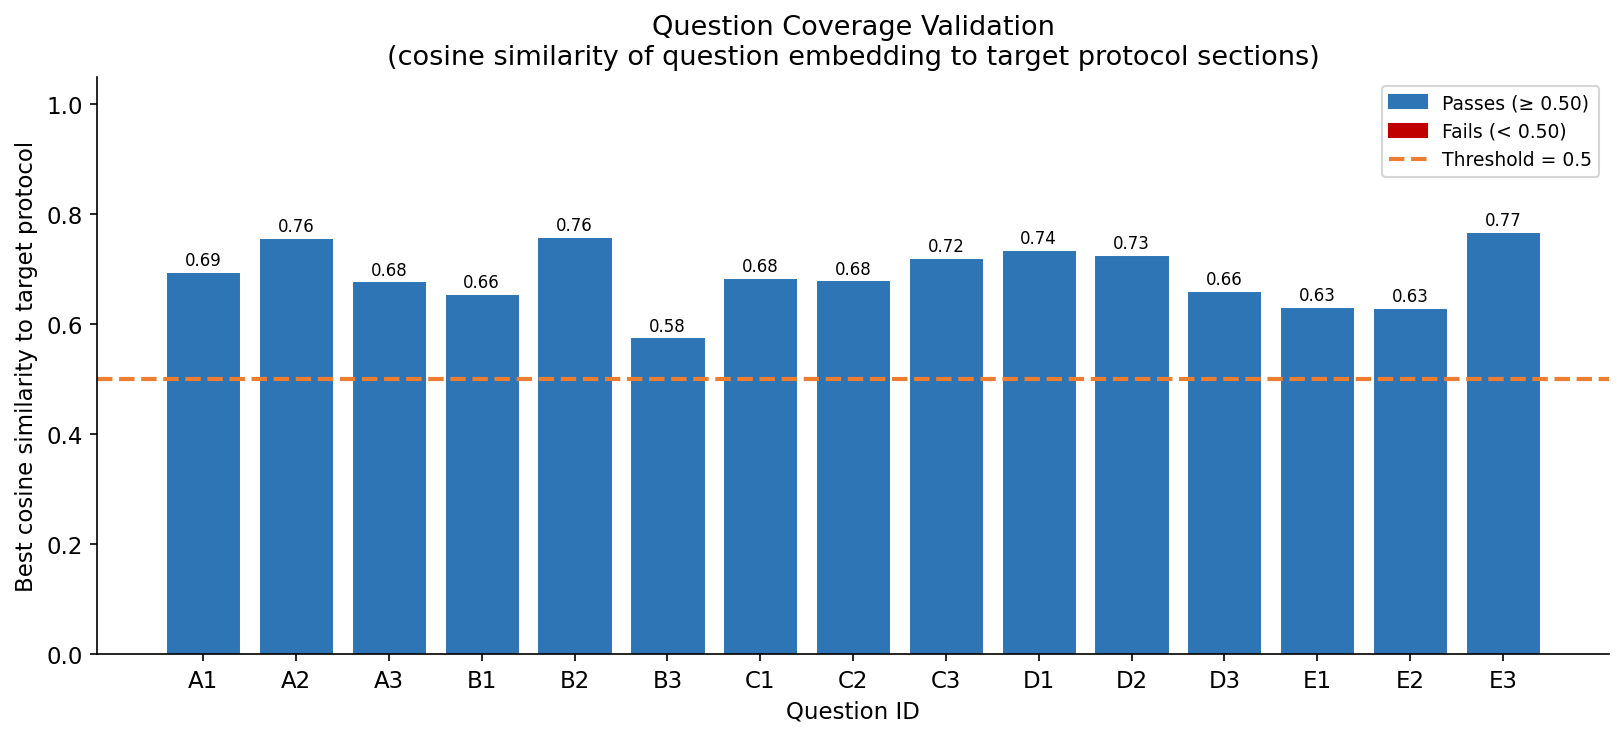

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))

colors = ["#2E75B6" if p else "#C00000" for p in df_cov["passes"]]
bars = ax.bar(df_cov["id"], df_cov["best_target_sim"],
              color=colors, edgecolor="white", linewidth=0.5)

ax.axhline(COVERAGE_THRESHOLD, color="#ED7D31", linewidth=2,
           linestyle="--", label=f"Threshold = {COVERAGE_THRESHOLD}")

for bar, val in zip(bars, df_cov["best_target_sim"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xlabel("Question ID")
ax.set_ylabel("Best cosine similarity to target protocol")
ax.set_title("Question Coverage Validation\n"
             "(cosine similarity of question embedding to target protocol sections)")
ax.set_ylim(0, 1.05)

legend_patches = [
    mpatches.Patch(color="#2E75B6", label="Passes (≥ 0.50)"),
    mpatches.Patch(color="#C00000", label="Fails (< 0.50)"),
]
ax.legend(handles=legend_patches + ax.get_legend_handles_labels()[0],
          fontsize=9)

fig.savefig(OUT_DIR / "fig_question_coverage.png", bbox_inches="tight")
plt.show()

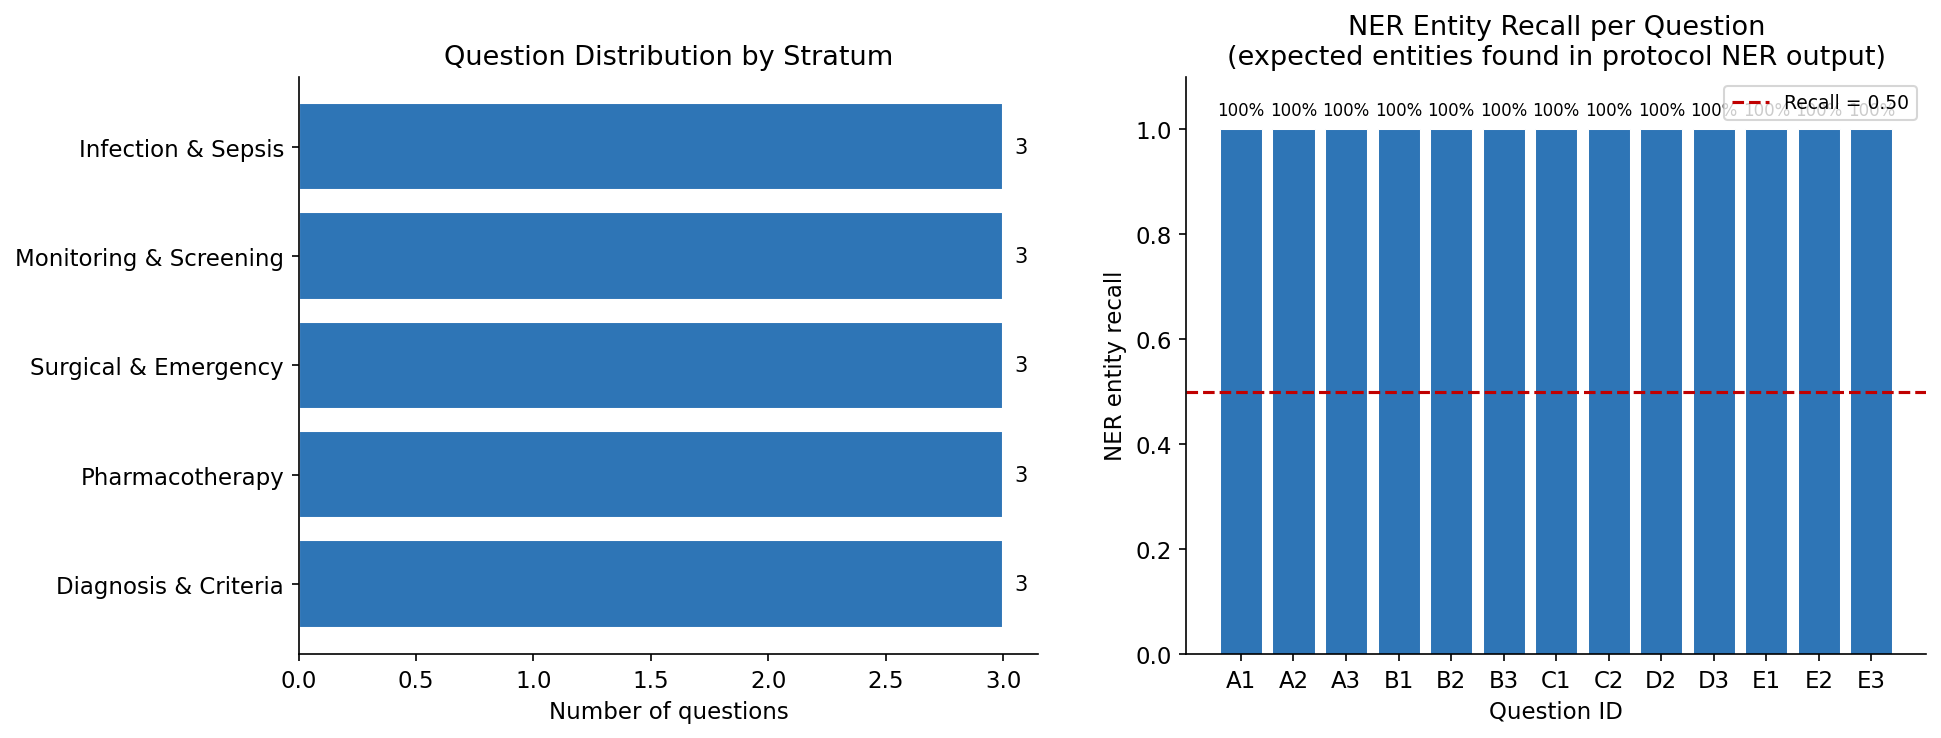

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stratum_counts = df_q["stratum"].value_counts()
axes[0].barh(stratum_counts.index, stratum_counts.values,
             color="#2E75B6", edgecolor="white")
axes[0].set_xlabel("Number of questions")
axes[0].set_title("Question Distribution by Stratum")
for i, v in enumerate(stratum_counts.values):
    axes[0].text(v + 0.05, i, str(v), va="center", fontsize=10)

df_ner_plot = df_ner[df_ner["n_expected"] > 0].copy()
recall_vals = df_ner_plot["recall"].apply(lambda x: x if isinstance(x, float) else 0)
bar_colors  = ["#2E75B6" if v >= 0.5 else "#ED7D31" if v > 0 else "#C00000"
               for v in recall_vals]
axes[1].bar(df_ner_plot["id"], recall_vals, color=bar_colors,
            edgecolor="white", linewidth=0.5)
axes[1].axhline(0.5, color="#C00000", linewidth=1.5, linestyle="--",
                label="Recall = 0.50")
axes[1].set_xlabel("Question ID")
axes[1].set_ylabel("NER entity recall")
axes[1].set_title("NER Entity Recall per Question\n"
                  "(expected entities found in protocol NER output)")
axes[1].set_ylim(0, 1.1)
axes[1].legend(fontsize=9)
for bar, val in zip(axes[1].patches, recall_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val:.0%}", ha="center", va="bottom", fontsize=8)

fig.savefig(OUT_DIR / "fig_stratum_and_ner_recall.png", bbox_inches="tight")
plt.show()

## 9. Top2Vec Topic Diversity Check

Verify that questions map to diverse Top2Vec topics — ensures the question set
covers the full thematic space of the corpus, not just one clinical domain.

In [ ]:
if TOP2VEC_CSV.exists():
    df_topics = pd.read_csv(TOP2VEC_CSV)
    print(f"Top2Vec topics loaded: {len(df_topics)}")

    topic_vecs = model.encode(
        df_topics["keywords"].tolist(), convert_to_numpy=True
    )
    q_to_topic = cosine_similarity(q_vecs, topic_vecs).argmax(axis=1)
    n_distinct  = len(set(q_to_topic))

    df_q_topics = df_q[["id", "stratum"]].copy()
    df_q_topics["top2vec_topic"] = q_to_topic
    df_q_topics["topic_keywords"] = [
        df_topics.iloc[t]["keywords"][:60] for t in q_to_topic
    ]
    display(df_q_topics)

    print(f"\nQuestions map to {n_distinct} distinct Top2Vec topics out of {len(df_topics)}")
    if n_distinct < 5:
        print(" Low topic diversity — consider revising questions")
    else:
        print("Good topic diversity")
else:
    print("Top2Vec CSV not found — run top2vec_thesis.ipynb first, or skip this cell")

Top2Vec topics loaded: 10


,id,stratum,top2vec_topic,topic_keywords
0,A1,Diagnosis & Criteria,5,"clinical, intrauterine, clinically, translatio..."
1,A2,Diagnosis & Criteria,7,"examinations, clinical, clinically, examinatio..."
2,A3,Diagnosis & Criteria,9,"contraindicated, clinically, complications, su..."
3,B1,Pharmacotherapy,0,"intrauterine, cesarean, preeclampsia, obstetri..."
4,B2,Pharmacotherapy,9,"contraindicated, clinically, complications, su..."
5,B3,Pharmacotherapy,0,"intrauterine, cesarean, preeclampsia, obstetri..."
6,C1,Surgical & Emergency,9,"contraindicated, clinically, complications, su..."
7,C2,Surgical & Emergency,9,"contraindicated, clinically, complications, su..."
8,C3,Surgical & Emergency,9,"contraindicated, clinically, complications, su..."
9,D1,Monitoring & Screening,0,"intrauterine, cesarean, preeclampsia, obstetri..."



Questions map to 5 distinct Top2Vec topics out of 10
✅ Good topic diversity


## 10. Export

Saves `final_questions.json` (Phase II input) and `question_validation_report.csv`
(thesis appendix evidence for question set construction methodology).

In [ ]:
passing_ids = set(df_cov[df_cov["passes"]]["id"])
final_qs    = [q for q in CANDIDATE_QUESTIONS if q["id"] in passing_ids]

print(f"Questions passing coverage : {len(final_qs)} / {len(CANDIDATE_QUESTIONS)}")
if len(final_qs) < 15:
    print(f"⚠️  Only {len(final_qs)} pass — revise failing questions before running Phase II")

out_json = OUT_DIR / "final_questions.json"
out_json.write_text(json.dumps(final_qs, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"Saved: {out_json}")

df_report = df_cov.merge(df_ner[["id","n_expected","n_found","recall","missing"]], on="id")
df_report.to_csv(OUT_DIR / "question_validation_report.csv", index=False)
print(f"Saved: {OUT_DIR / 'question_validation_report.csv'}")

print("\n" + "="*55)
print("  QUESTION SET SUMMARY")
print("="*55)
print(f"  Total questions    : {len(CANDIDATE_QUESTIONS)}")
print(f"  Strata covered     : {df_q['stratum'].nunique()}")
print(f"  Passing coverage   : {len(final_qs)}")
avg_sim = df_cov[df_cov["passes"]]["best_target_sim"].mean()
print(f"  Mean target sim    : {avg_sim:.4f}")
print("="*55)

Questions passing coverage : 15 / 15
Saved: /content/drive/MyDrive/medical_protocols/question_design_v1/final_questions.json
Saved: /content/drive/MyDrive/medical_protocols/question_design_v1/question_validation_report.csv

  QUESTION SET SUMMARY
  Total questions    : 15
  Strata covered     : 5
  Passing coverage   : 15
  Mean target sim    : 0.6899
